from https://github.com/opencv/opencv/blob/master/samples/dnn/edge_detection.py


In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


1080 1080 3


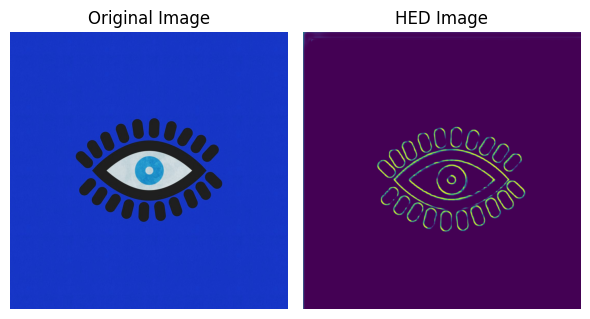

In [19]:

# Load the model.
net = cv.dnn.readNet(cv.samples.findFile('caffe_model/deploy.prototxt'), cv.samples.findFile('caffe_model/hed_pretrained_bsds.caffemodel'))


frame = cv.imread('testdata/red_eye.jpg')
height, width, channels = frame.shape
print (height, width, channels)


inp = cv.dnn.blobFromImage(frame, scalefactor=0.99, size=(height, width),
                            mean=(104.00698793, 116.66876762, 122.67891434),
                            swapRB=True, crop=True)
net.setInput(inp)

out = net.forward()
out = out[0, 0]
out = cv.resize(out, (frame.shape[1], frame.shape[0]))

plt.figure(figsize=(6, 6))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(frame)
plt.title('Original Image')
plt.axis('off')

# Modified image
plt.subplot(1, 2, 2)
plt.imshow(out)
plt.title('HED Image')
plt.axis('off')
plt.tight_layout()
plt.show()
